In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/heart_disease_uci.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 920
Number of columns: 16


In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [6]:
print("Columns in the dataset:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:
1. id
2. age
3. sex
4. dataset
5. cp
6. trestbps
7. chol
8. fbs
9. restecg
10. thalch
11. exang
12. oldpeak
13. slope
14. ca
15. thal
16. num


In [7]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [9]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values by column:")
print(missing_values)

Missing values by column:
ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Values,Missing Percentage
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
exang,55,5.978261
thalch,55,5.978261
chol,30,3.260870
restecg,2,0.217391


In [11]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [12]:
duplicate_ids = df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

Number of duplicate IDs: 0


In [13]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [15]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [16]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- sex ---
sex
Male      726
Female    194
Name: count, dtype: int64

--- dataset ---
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

--- cp ---
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

--- fbs ---
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

--- restecg ---
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

--- exang ---
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

--- slope ---
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

--- thal ---
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [18]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [19]:
print("Target variable: num")

print("\nUnique values:")
print(sorted(df["num"].unique()))

print("\nValue counts:")
print(df["num"].value_counts().sort_index())

Target variable: num

Unique values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [20]:
target_distribution = df["num"].value_counts().sort_index()

target_percentage = (
    df["num"].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_distribution,
    "Percentage": target_percentage
})

target_summary

,Count,Percentage
num,,
0,411,44.67
1,265,28.80
2,109,11.85
3,107,11.63
4,28,3.04


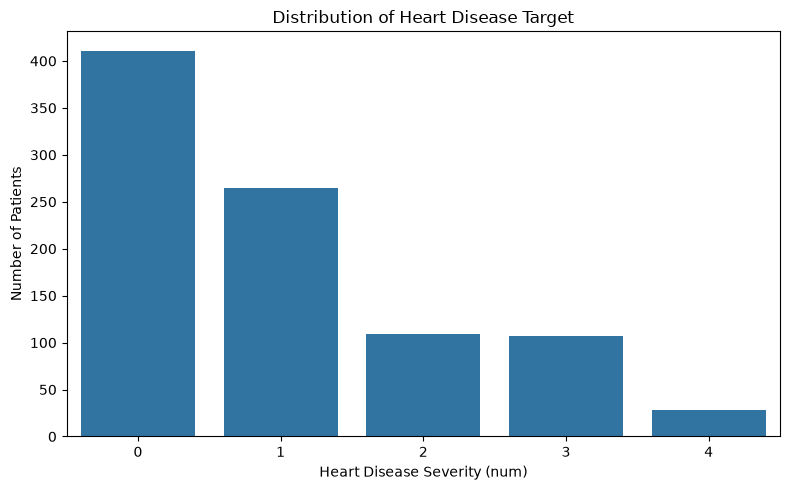

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="num",
    order=sorted(df["num"].dropna().unique())
)

plt.title("Distribution of Heart Disease Target")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

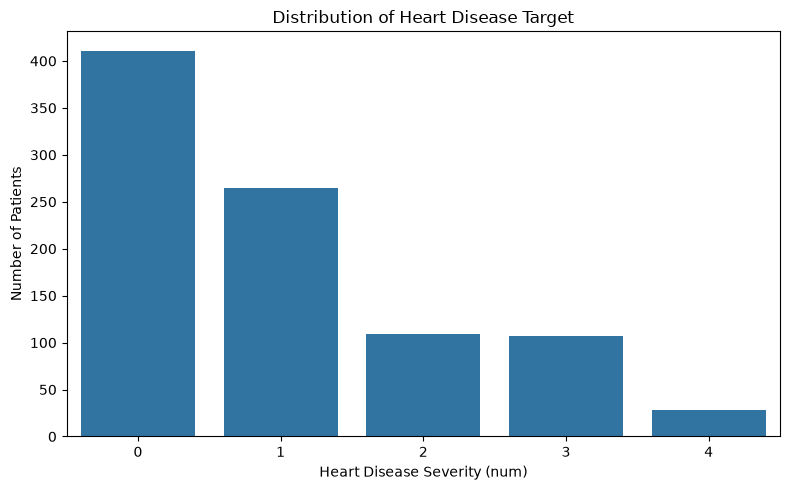

Graph saved successfully to reports/target_distribution.png


In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="num",
    order=sorted(df["num"].dropna().unique())
)

plt.title("Distribution of Heart Disease Target")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Number of Patients")

plt.tight_layout()

# Save the figure
plt.savefig("../reports/target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved successfully to reports/target_distribution.png")

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [24]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [25]:
duplicate_ids = df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

Number of duplicate IDs: 0


In [26]:
for column in df.columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {column}")
    print(f"Data Type: {df[column].dtype}")
    print(f"Unique Values: {df[column].nunique()}")
    print(df[column].unique())


Column: id
Data Type: int64
Unique Values: 920
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 23

In [27]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [28]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- sex ---
sex
Male      726
Female    194
Name: count, dtype: int64

--- dataset ---
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

--- cp ---
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

--- fbs ---
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

--- restecg ---
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

--- exang ---
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

--- slope ---
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

--- thal ---
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [29]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [30]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [31]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [32]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Missing Percentage
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


In [33]:
for column in numerical_columns:
    print(f"\n--- {column} ---")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


--- id ---
Minimum: 1
Maximum: 920

--- age ---
Minimum: 28
Maximum: 77

--- trestbps ---
Minimum: 0.0
Maximum: 200.0

--- chol ---
Minimum: 0.0
Maximum: 603.0

--- thalch ---
Minimum: 60.0
Maximum: 202.0

--- oldpeak ---
Minimum: -2.6
Maximum: 6.2

--- ca ---
Minimum: 0.0
Maximum: 3.0

--- num ---
Minimum: 0
Maximum: 4


In [34]:
print("Target variable: num")

print("\nUnique values:")
print(sorted(df["num"].dropna().unique()))

print("\nValue counts:")
print(df["num"].value_counts(dropna=False).sort_index())

Target variable: num

Unique values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [42]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Missing Percentage
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


In [43]:
missing_summary.to_csv(
    "../reports/missing_value_summary.csv",
    index=True
)

print("Missing-value summary saved successfully.")

Missing-value summary saved successfully.


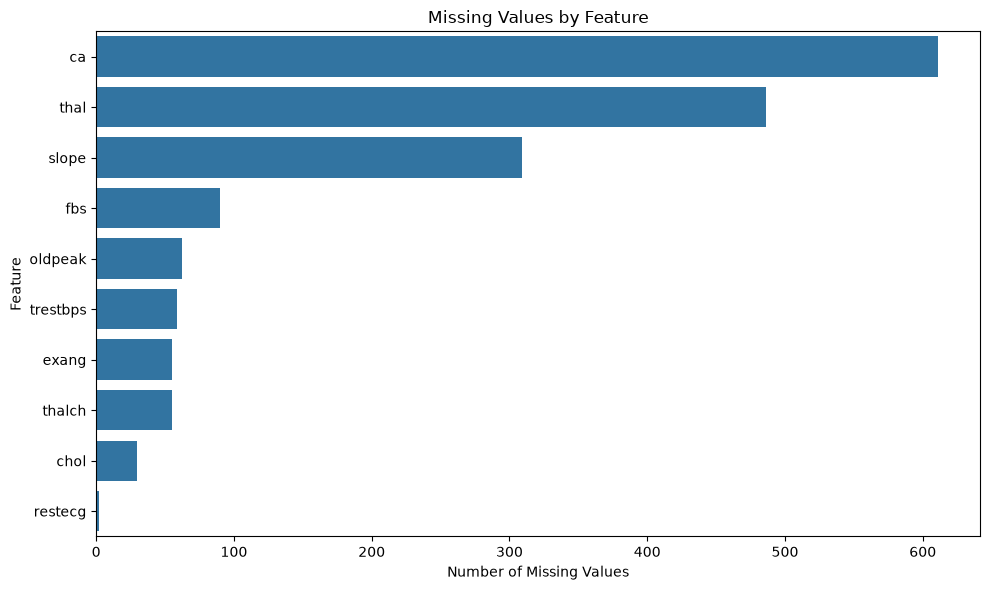

Missing-value graph saved successfully.


In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_summary["Missing Values"],
    y=missing_summary.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Missing-value graph saved successfully.")

In [45]:
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]

overall_missing_percentage = (total_missing / total_cells) * 100

print("Total missing values:", total_missing)
print("Total cells:", total_cells)
print(f"Overall missing percentage: {overall_missing_percentage:.2f}%")

Total missing values: 1759
Total cells: 14720
Overall missing percentage: 11.95%


In [46]:
missing_by_target = df.groupby("num").apply(
    lambda group: group.isnull().sum().sum()
)

missing_by_target

num
0    777
1    536
2    191
3    212
4     43
dtype: int64

In [47]:
missing_summary

,Missing Values,Missing Percentage
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


In [48]:
df.dropna()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,300,68,Male,Cleveland,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,2
300,301,57,Male,Cleveland,asymptomatic,130.0,131.0,False,normal,115.0,True,1.2,flat,1.0,reversable defect,3
301,302,57,Female,Cleveland,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,1
508,509,47,Male,Hungary,asymptomatic,150.0,226.0,False,normal,98.0,True,1.5,flat,0.0,reversable defect,1


In [49]:
missing_by_dataset = df.groupby("dataset").agg(
    total_records=("id", "count"),
    missing_ca=("ca", lambda x: x.isna().sum()),
    missing_thal=("thal", lambda x: x.isna().sum()),
    missing_slope=("slope", lambda x: x.isna().sum())
)

missing_by_dataset

,total_records,missing_ca,missing_thal,missing_slope
dataset,,,,
Cleveland,304,5,3,1
Hungary,293,290,265,189
Switzerland,123,118,52,17
VA Long Beach,200,198,166,102


In [50]:
missing_by_dataset_percentage = missing_by_dataset.copy()

for column in ["missing_ca", "missing_thal", "missing_slope"]:
    missing_by_dataset_percentage[column] = (
        missing_by_dataset[column]
        / missing_by_dataset["total_records"]
        * 100
    ).round(2)

missing_by_dataset_percentage

,total_records,missing_ca,missing_thal,missing_slope
dataset,,,,
Cleveland,304,1.64,0.99,0.33
Hungary,293,98.98,90.44,64.51
Switzerland,123,95.93,42.28,13.82
VA Long Beach,200,99.00,83.00,51.00


In [51]:
missing_by_target = df.groupby("num").agg(
    total_records=("id", "count"),
    missing_ca=("ca", lambda x: x.isna().sum()),
    missing_thal=("thal", lambda x: x.isna().sum()),
    missing_slope=("slope", lambda x: x.isna().sum())
)

missing_by_target

,total_records,missing_ca,missing_thal,missing_slope
num,,,,
0,411,246,224,193
1,265,207,159,67
2,109,73,46,19
3,107,70,45,26
4,28,15,12,4


In [52]:
missing_by_target_percentage = missing_by_target.copy()

for column in ["missing_ca", "missing_thal", "missing_slope"]:
    missing_by_target_percentage[column] = (
        missing_by_target[column]
        / missing_by_target["total_records"]
        * 100
    ).round(2)

missing_by_target_percentage

,total_records,missing_ca,missing_thal,missing_slope
num,,,,
0,411,59.85,54.50,46.96
1,265,78.11,60.00,25.28
2,109,66.97,42.20,17.43
3,107,65.42,42.06,24.30
4,28,53.57,42.86,14.29


In [53]:
high_missing_features = ["ca", "thal", "slope"]

for column in high_missing_features:
    df[f"{column}_missing"] = df[column].isna().astype(int)

df[[
    "ca_missing",
    "thal_missing",
    "slope_missing"
]].value_counts()

ca_missing  thal_missing  slope_missing
0           0             0                299
1           1             1                257
                          0                219
            0             0                 86
                          1                 49
0           1             0                  7
                          1                  3
Name: count, dtype: int64

In [54]:
for column in ["ca_missing", "thal_missing", "slope_missing"]:
    print(f"\n--- {column} by target ---")
    print(
        pd.crosstab(
            df[column],
            df["num"],
            normalize="columns"
        ).round(3)
    )


--- ca_missing by target ---
num             0      1     2      3      4
ca_missing                                  
0           0.401  0.219  0.33  0.346  0.464
1           0.599  0.781  0.67  0.654  0.536

--- thal_missing by target ---
num               0    1      2      3      4
thal_missing                                 
0             0.455  0.4  0.578  0.579  0.571
1             0.545  0.6  0.422  0.421  0.429

--- slope_missing by target ---
num               0      1      2      3      4
slope_missing                                  
0              0.53  0.747  0.826  0.757  0.857
1              0.47  0.253  0.174  0.243  0.143


In [55]:
dataset_target = pd.crosstab(
    df["dataset"],
    df["num"],
    normalize="index"
).round(3)

dataset_target

num,0,1,2,3,4
dataset,,,,,
Cleveland,0.543,0.181,0.118,0.115,0.043
Hungary,0.638,0.362,0.000,0.000,0.000
Switzerland,0.065,0.390,0.260,0.244,0.041
VA Long Beach,0.255,0.280,0.205,0.210,0.050


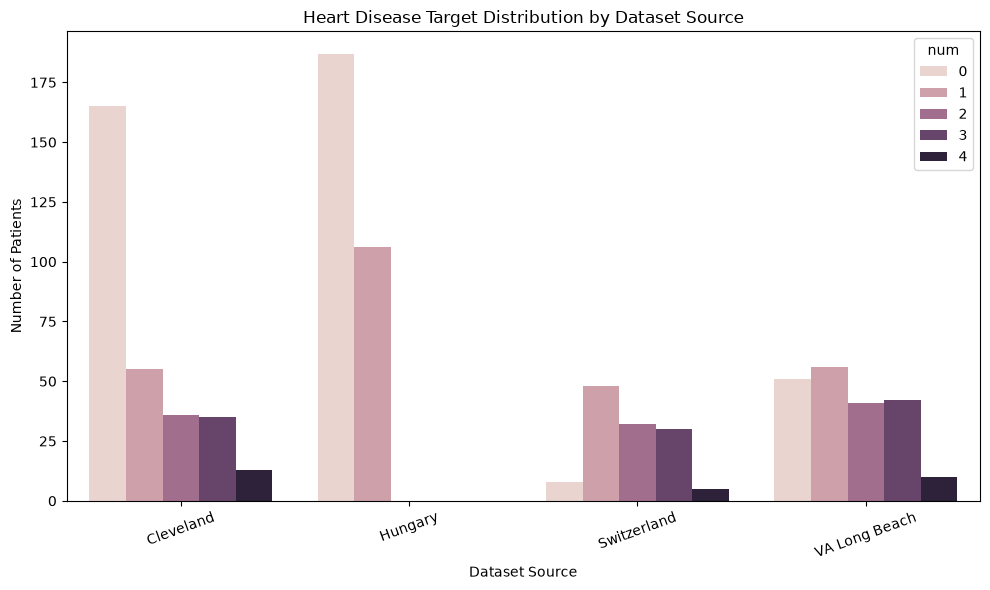

In [56]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="dataset",
    hue="num"
)

plt.title("Heart Disease Target Distribution by Dataset Source")
plt.xlabel("Dataset Source")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../reports/target_by_dataset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Data Cleaning


In [57]:
df_clean = df.copy()

print("Working copy created.")
print("Shape:", df_clean.shape)

Working copy created.
Shape: (920, 19)


In [58]:
df_clean = df_clean.drop(columns=["id"])

print("ID column removed.")
print("Shape:", df_clean.shape)

ID column removed.
Shape: (920, 18)


In [59]:
df_clean["trestbps"] = df_clean["trestbps"].replace(0, np.nan)
df_clean["chol"] = df_clean["chol"].replace(0, np.nan)

print("Invalid zero values converted to NaN.")

Invalid zero values converted to NaN.


In [60]:
high_missing_features = ["ca", "thal", "slope"]

for column in high_missing_features:
    df_clean[f"{column}_missing"] = df_clean[column].isna().astype(int)

print("Missingness indicators created.")

Missingness indicators created.


In [61]:
df_clean.isnull().sum().sort_values(ascending=False)

ca               611
thal             486
slope            309
chol             202
fbs               90
oldpeak           62
trestbps          60
thalch            55
exang             55
restecg            2
sex                0
age                0
cp                 0
dataset            0
num                0
ca_missing         0
thal_missing       0
slope_missing      0
dtype: int64

In [62]:
df_clean.to_csv(
    "../data/processed/heart_disease_cleaned_intermediate.csv",
    index=False
)

print("Intermediate cleaned dataset saved successfully.")

Intermediate cleaned dataset saved successfully.


In [63]:
df_clean.isnull().sum().sort_values(ascending=False)

ca               611
thal             486
slope            309
chol             202
fbs               90
oldpeak           62
trestbps          60
thalch            55
exang             55
restecg            2
sex                0
age                0
cp                 0
dataset            0
num                0
ca_missing         0
thal_missing       0
slope_missing      0
dtype: int64

In [64]:
numerical_impute_columns = [
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

for column in numerical_impute_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

print("Numerical missing values imputed using median.")

Numerical missing values imputed using median.


In [65]:
df_clean[numerical_impute_columns].isnull().sum()

trestbps    0
chol        0
thalch      0
oldpeak     0
ca          0
dtype: int64

In [66]:
categorical_mode_columns = [
    "fbs",
    "exang",
    "restecg"
]

for column in categorical_mode_columns:
    mode_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(mode_value)

print("Categorical missing values imputed using mode.")

Categorical missing values imputed using mode.


In [67]:
df_clean["thal"] = df_clean["thal"].fillna("Missing")
df_clean["slope"] = df_clean["slope"].fillna("Missing")

print("Missing categories preserved as 'Missing'.")

Missing categories preserved as 'Missing'.


In [68]:
remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Series([], dtype: int64)


In [69]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 920
Columns: 18


In [70]:
df_clean.to_csv(
    "../data/processed/heart_disease_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [71]:
remaining_missing

Series([], dtype: int64)

In [72]:
df_clean.shape

(920, 18)

## 5. Exploratory Data Analysis (EDA)

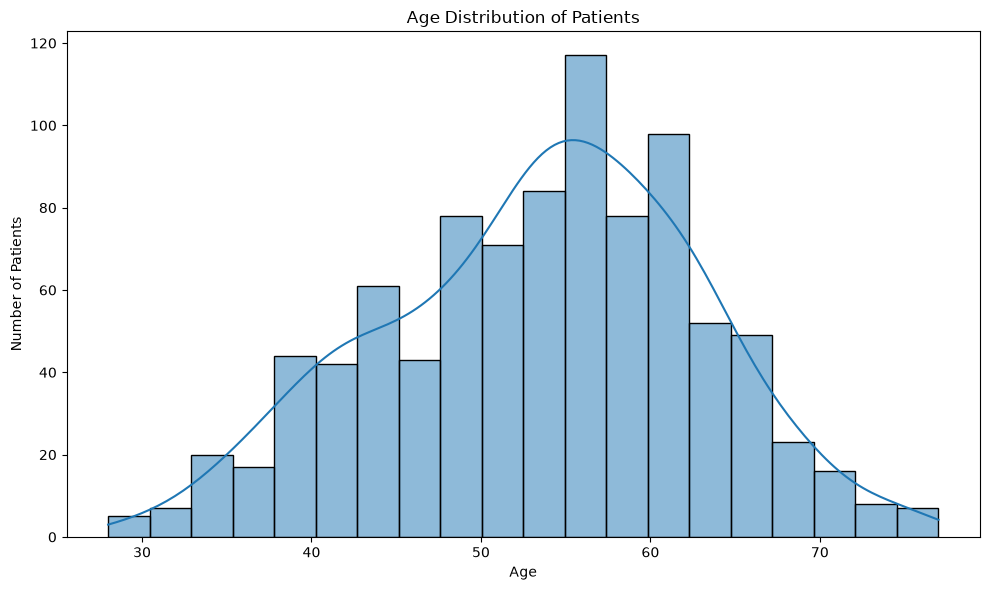

Age distribution graph saved successfully.


In [73]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Age distribution graph saved successfully.")

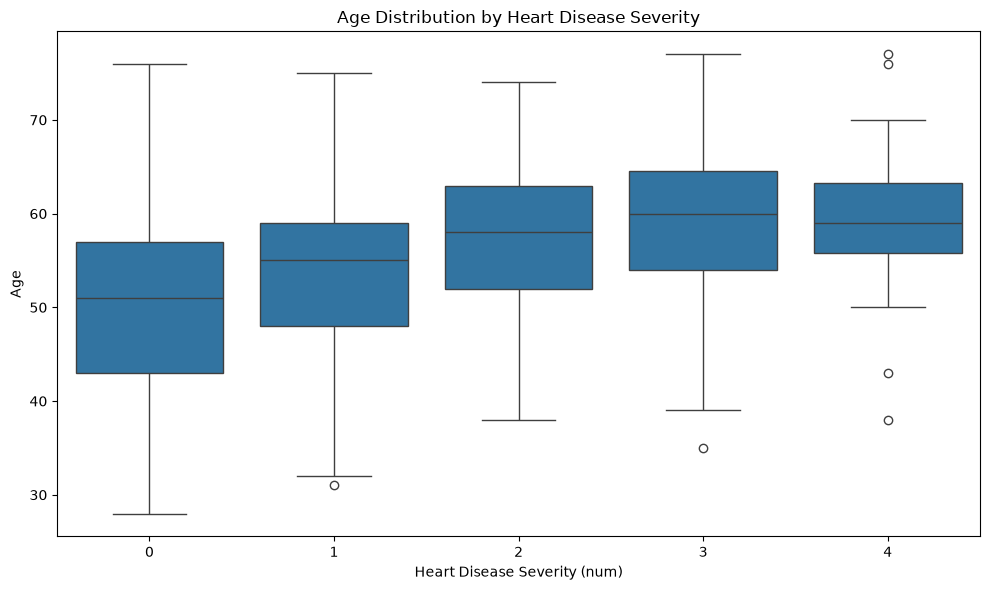

Age vs heart disease graph saved successfully.


In [74]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="num",
    y="age"
)

plt.title("Age Distribution by Heart Disease Severity")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Age")

plt.tight_layout()

plt.savefig(
    "../reports/age_by_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Age vs heart disease graph saved successfully.")

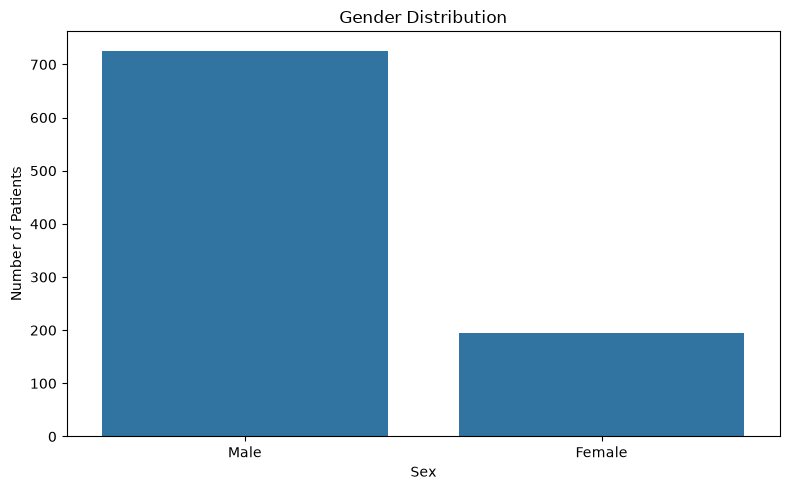

Gender distribution graph saved successfully.


In [75]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="sex"
)

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gender distribution graph saved successfully.")

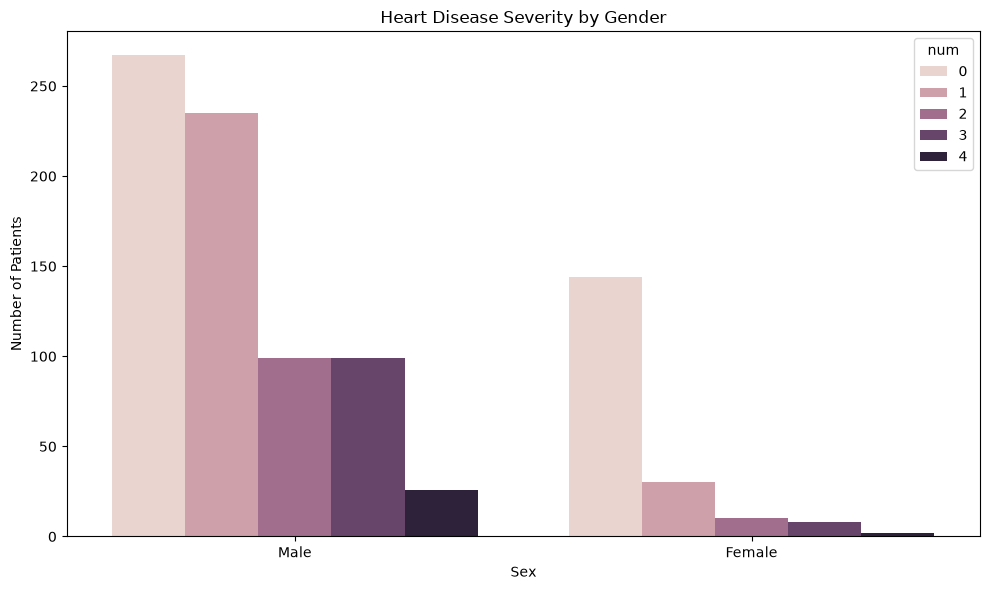

Heart disease by gender graph saved successfully.


In [76]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="sex",
    hue="num"
)

plt.title("Heart Disease Severity by Gender")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Heart disease by gender graph saved successfully.")

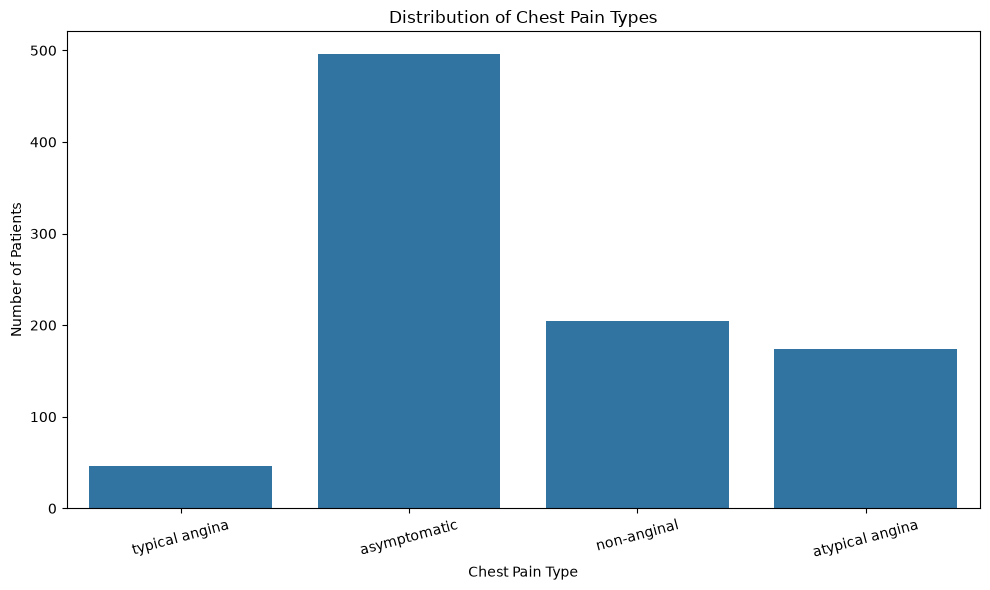

Chest pain distribution graph saved successfully.


In [77]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="cp"
)

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/chest_pain_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chest pain distribution graph saved successfully.")

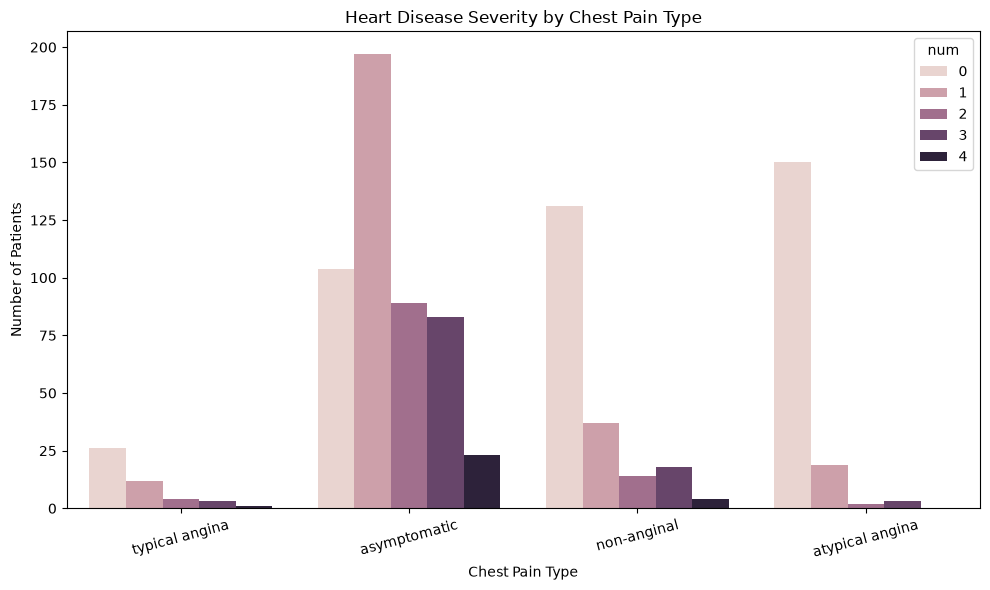

Chest pain vs heart disease graph saved successfully.


In [78]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="cp",
    hue="num"
)

plt.title("Heart Disease Severity by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_chest_pain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chest pain vs heart disease graph saved successfully.")

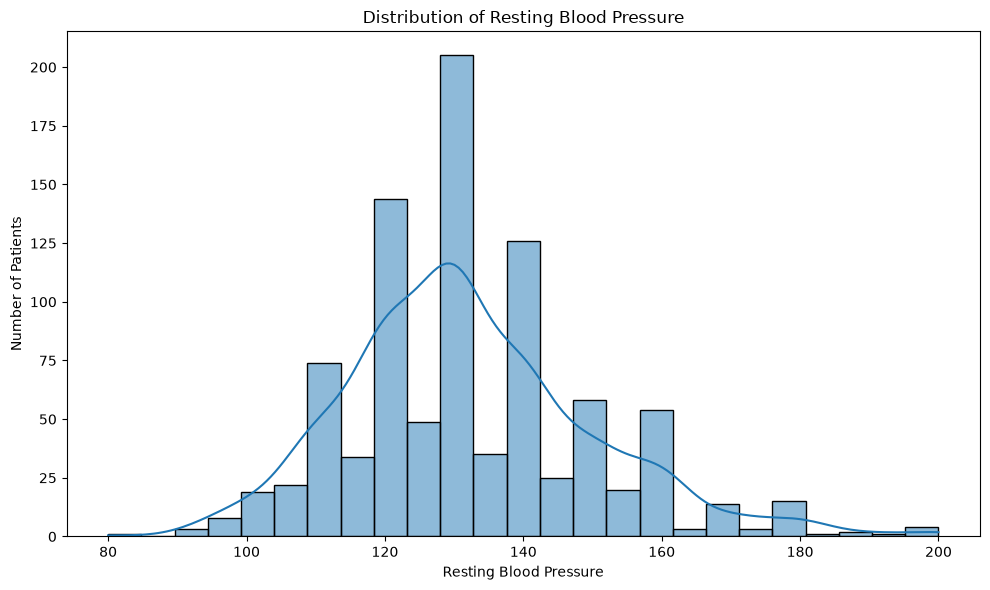

Resting blood pressure graph saved successfully.


In [79]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="trestbps",
    bins=25,
    kde=True
)

plt.title("Distribution of Resting Blood Pressure")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/resting_blood_pressure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Resting blood pressure graph saved successfully.")

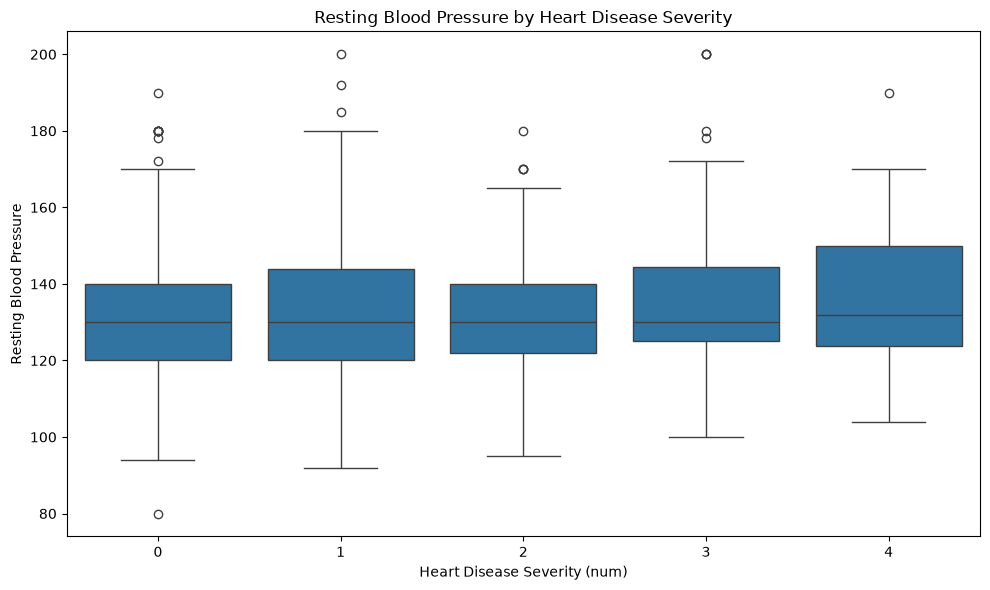

Blood pressure vs heart disease graph saved successfully.


In [80]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="num",
    y="trestbps"
)

plt.title("Resting Blood Pressure by Heart Disease Severity")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Resting Blood Pressure")

plt.tight_layout()

plt.savefig(
    "../reports/blood_pressure_by_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Blood pressure vs heart disease graph saved successfully.")

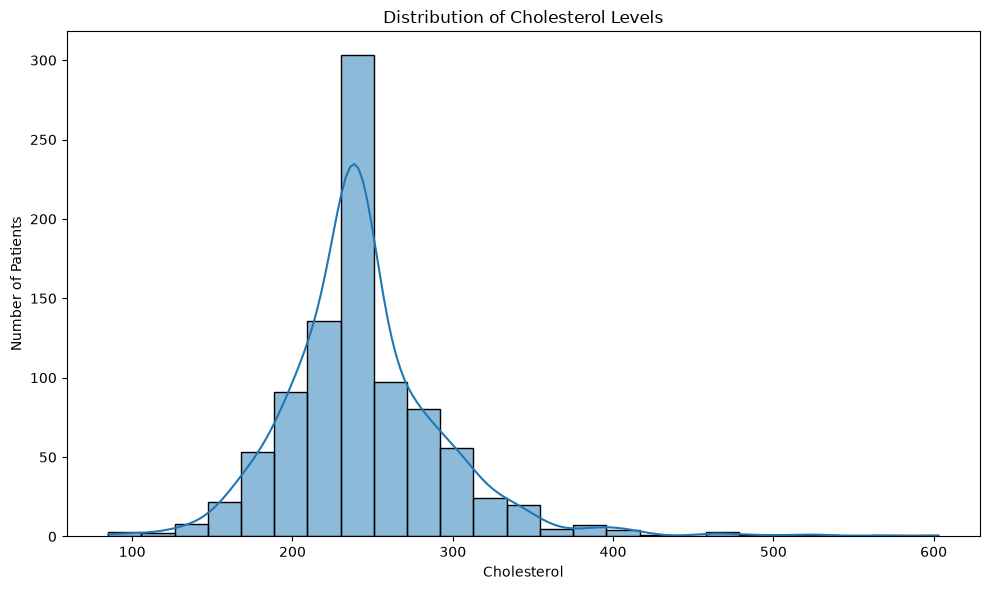

Cholesterol distribution graph saved successfully.


In [81]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="chol",
    bins=25,
    kde=True
)

plt.title("Distribution of Cholesterol Levels")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/cholesterol_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cholesterol distribution graph saved successfully.")

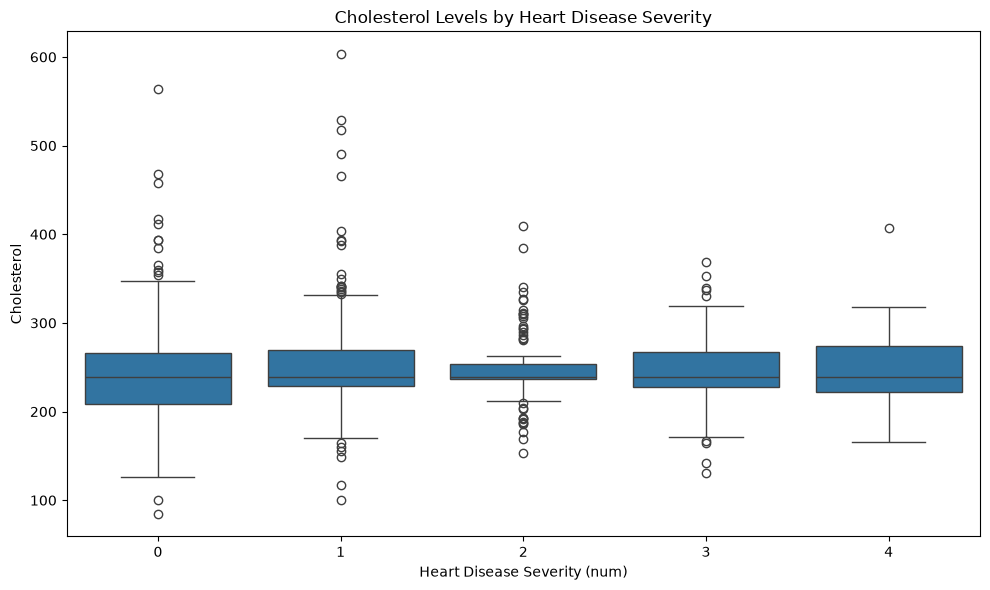

Cholesterol vs heart disease graph saved successfully.


In [82]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="num",
    y="chol"
)

plt.title("Cholesterol Levels by Heart Disease Severity")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Cholesterol")

plt.tight_layout()

plt.savefig(
    "../reports/cholesterol_by_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cholesterol vs heart disease graph saved successfully.")

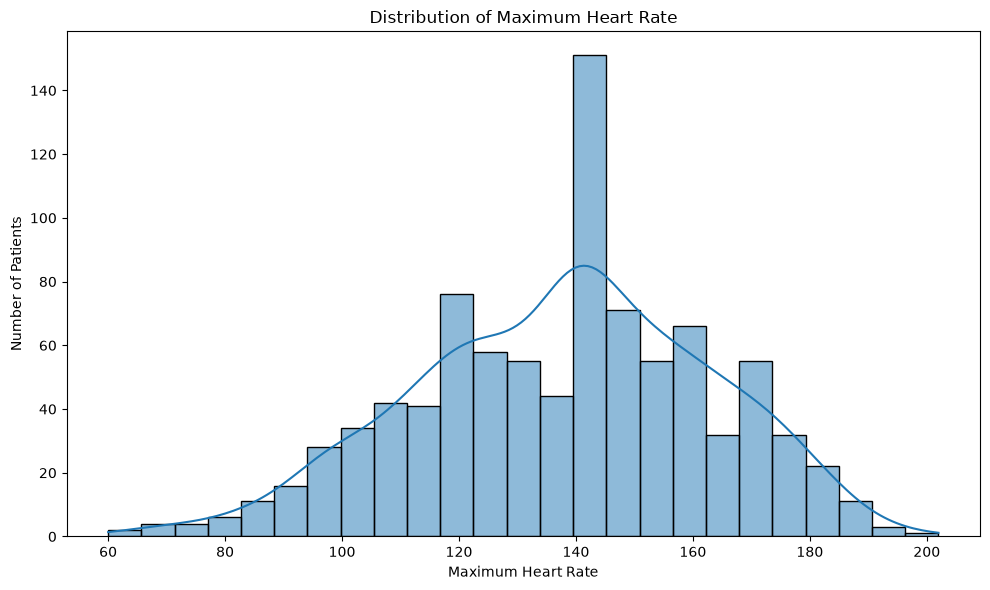

Maximum heart rate graph saved successfully.


In [83]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="thalch",
    bins=25,
    kde=True
)

plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/maximum_heart_rate_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Maximum heart rate graph saved successfully.")

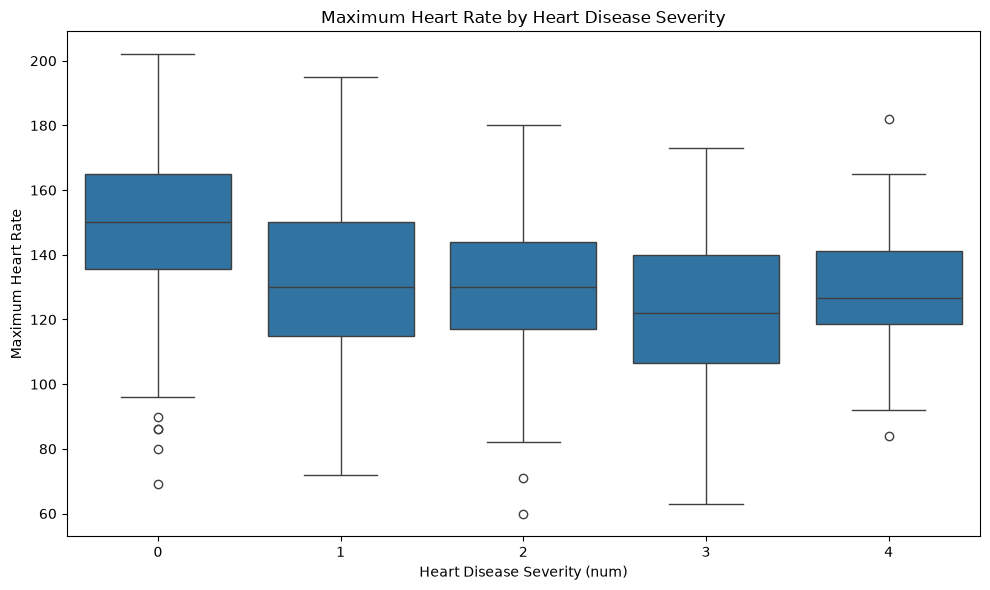

Maximum heart rate vs heart disease graph saved successfully.


In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="num",
    y="thalch"
)

plt.title("Maximum Heart Rate by Heart Disease Severity")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Maximum Heart Rate")

plt.tight_layout()

plt.savefig(
    "../reports/maximum_heart_rate_by_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Maximum heart rate vs heart disease graph saved successfully.")

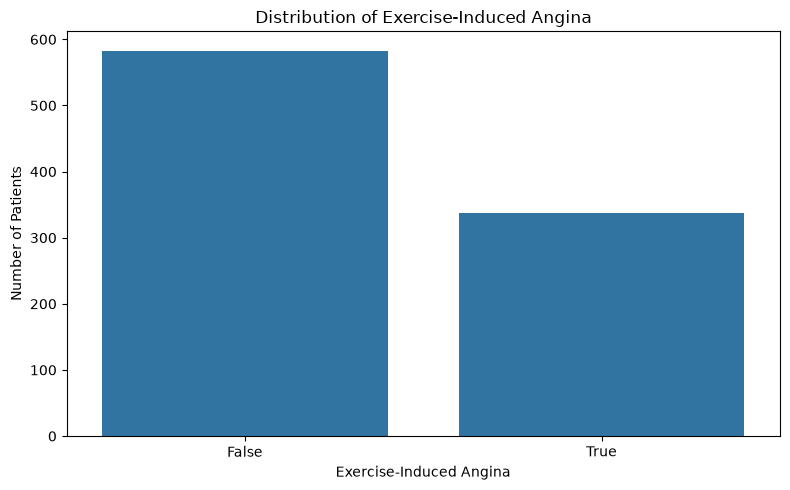

Exercise-induced angina graph saved successfully.


In [85]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="exang"
)

plt.title("Distribution of Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/exercise_angina_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Exercise-induced angina graph saved successfully.")

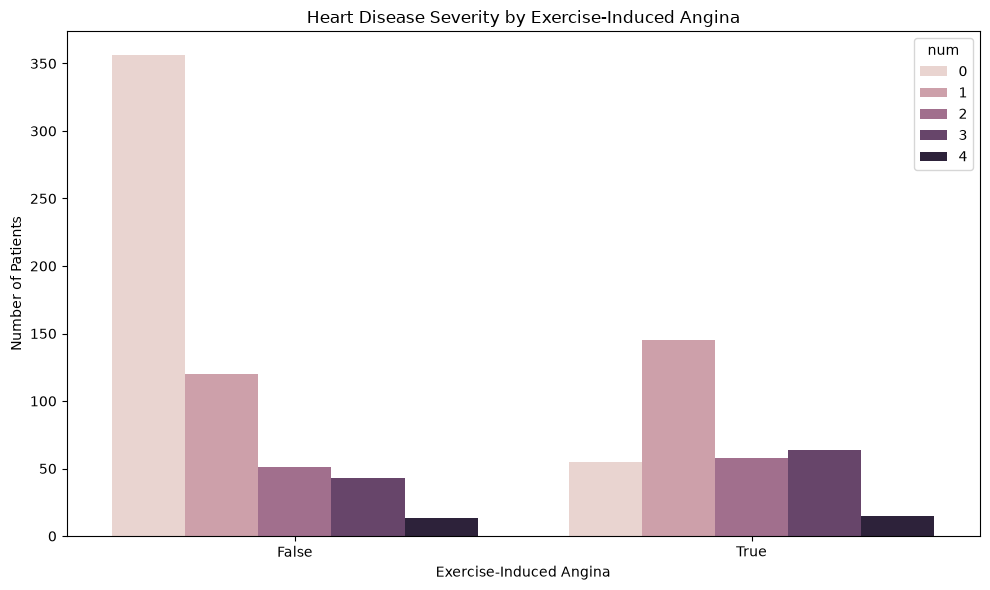

Exercise-induced angina vs heart disease graph saved successfully.


In [86]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="exang",
    hue="num"
)

plt.title("Heart Disease Severity by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_exercise_angina.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Exercise-induced angina vs heart disease graph saved successfully.")

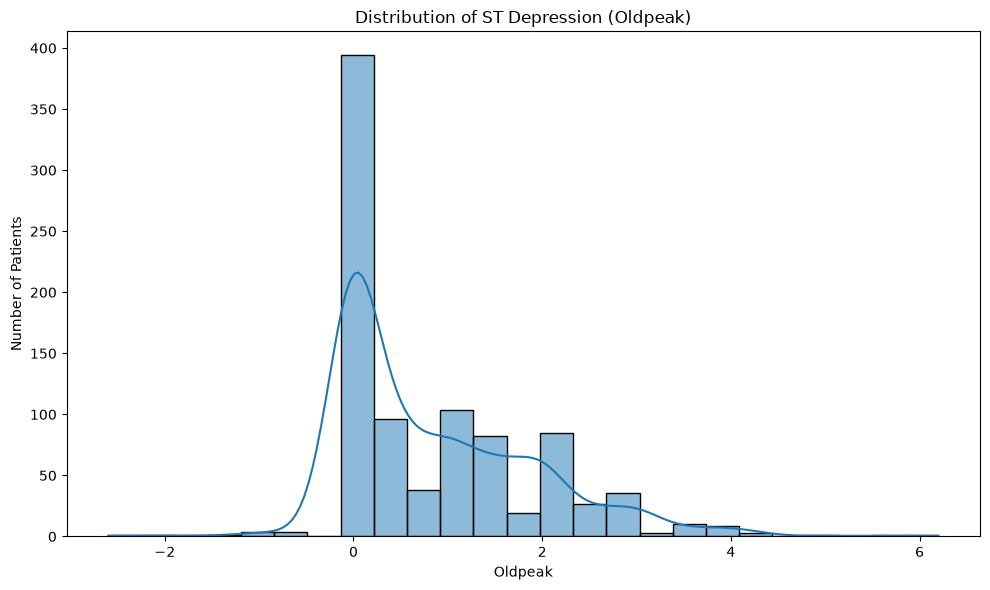

Oldpeak distribution graph saved successfully.


In [87]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="oldpeak",
    bins=25,
    kde=True
)

plt.title("Distribution of ST Depression (Oldpeak)")
plt.xlabel("Oldpeak")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/oldpeak_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Oldpeak distribution graph saved successfully.")

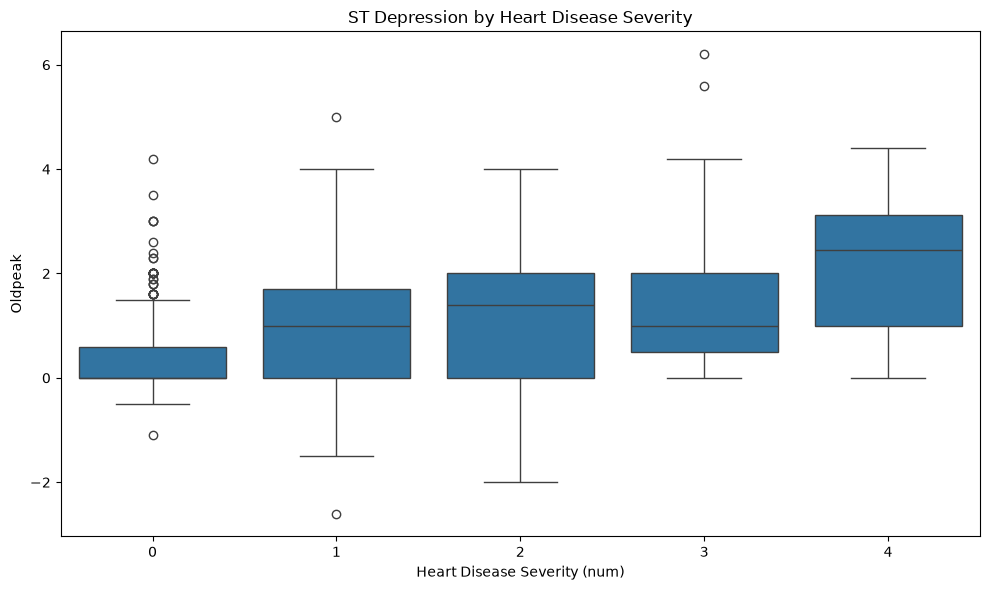

Oldpeak vs heart disease graph saved successfully.


In [88]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="num",
    y="oldpeak"
)

plt.title("ST Depression by Heart Disease Severity")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Oldpeak")

plt.tight_layout()

plt.savefig(
    "../reports/oldpeak_by_heart_disease.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Oldpeak vs heart disease graph saved successfully.")

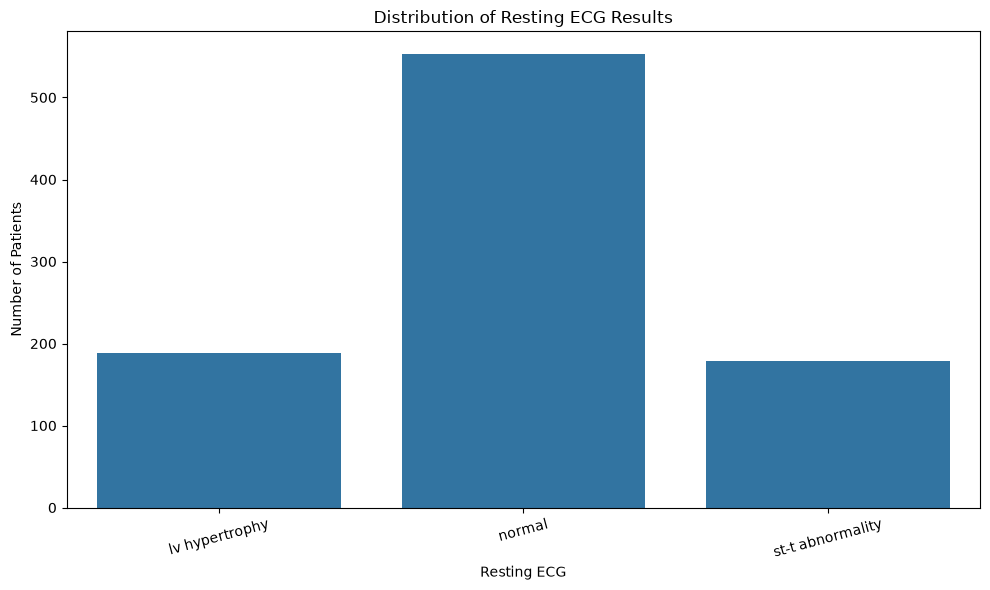

Resting ECG graph saved successfully.


In [89]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="restecg"
)

plt.title("Distribution of Resting ECG Results")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/restecg_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Resting ECG graph saved successfully.")

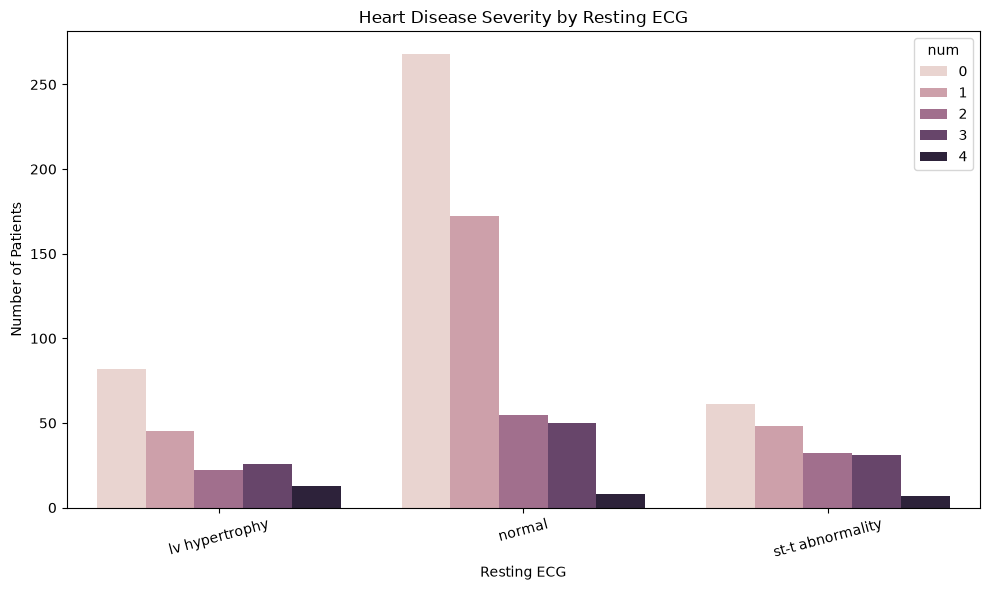

Resting ECG vs heart disease graph saved successfully.


In [90]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="restecg",
    hue="num"
)

plt.title("Heart Disease Severity by Resting ECG")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_restecg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Resting ECG vs heart disease graph saved successfully.")

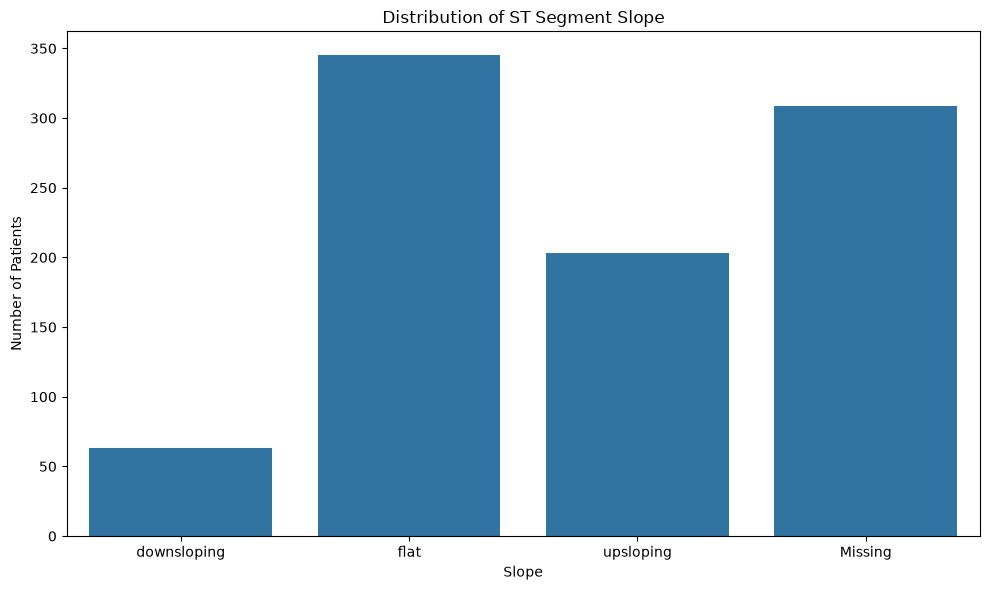

Slope distribution graph saved successfully.


In [91]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="slope"
)

plt.title("Distribution of ST Segment Slope")
plt.xlabel("Slope")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/slope_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Slope distribution graph saved successfully.")

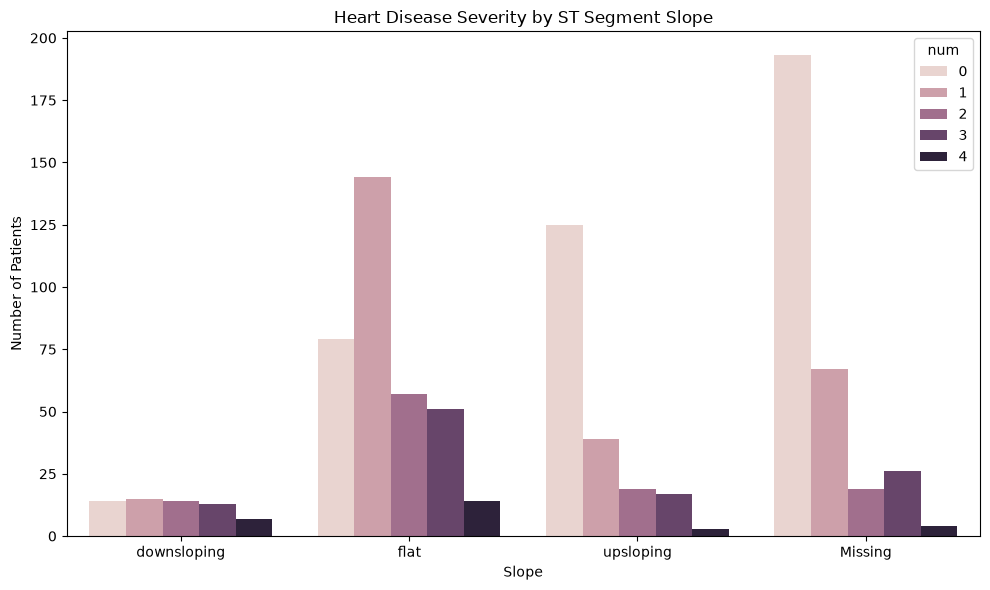

Slope vs heart disease graph saved successfully.


In [92]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="slope",
    hue="num"
)

plt.title("Heart Disease Severity by ST Segment Slope")
plt.xlabel("Slope")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_slope.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Slope vs heart disease graph saved successfully.")

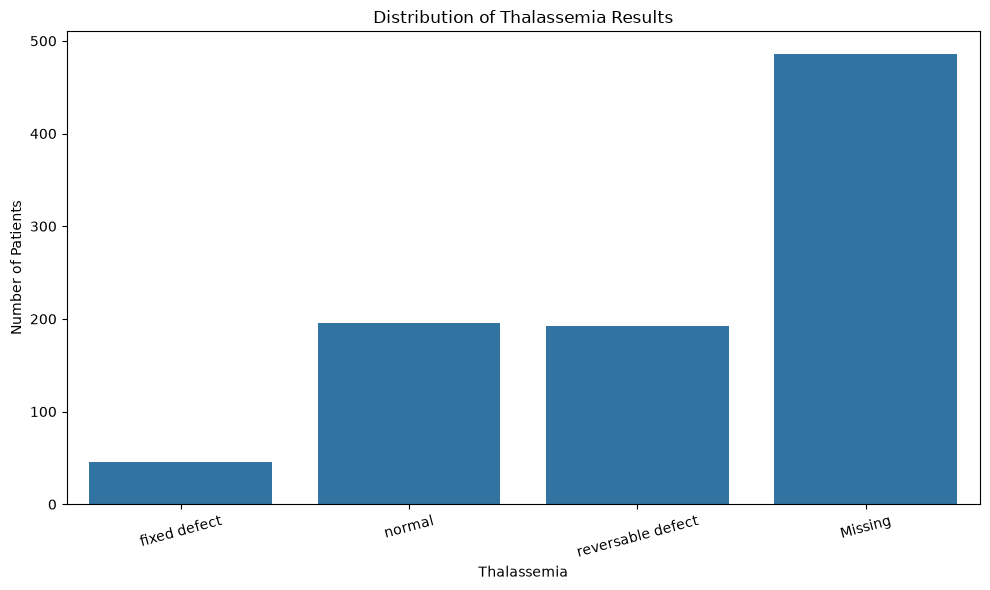

Thal distribution graph saved successfully.


In [93]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="thal"
)

plt.title("Distribution of Thalassemia Results")
plt.xlabel("Thalassemia")
plt.ylabel("Number of Patients")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/thal_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Thal distribution graph saved successfully.")

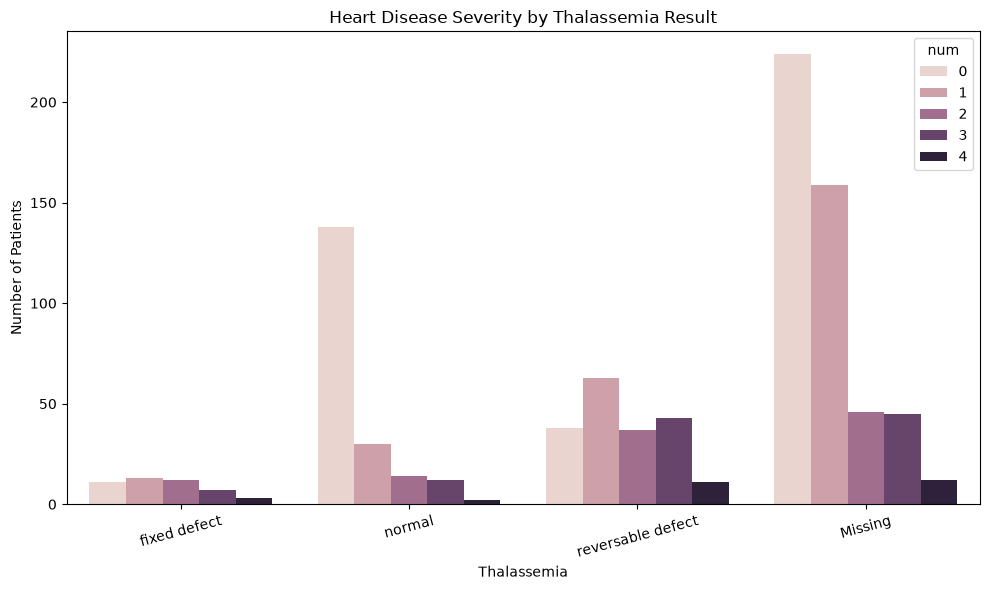

Thal vs heart disease graph saved successfully.


In [94]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="thal",
    hue="num"
)

plt.title("Heart Disease Severity by Thalassemia Result")
plt.xlabel("Thalassemia")
plt.ylabel("Number of Patients")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/heart_disease_by_thal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Thal vs heart disease graph saved successfully.")

In [95]:
correlation_columns = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
    "num"
]

correlation_matrix = df_clean[correlation_columns].corr()

correlation_matrix

,age,trestbps,chol,thalch,oldpeak,ca,num
age,1.000000,0.238744,0.067105,-0.349715,0.233550,0.219413,0.339596
trestbps,0.238744,1.000000,0.075995,-0.102364,0.170730,0.037380,0.130309
chol,0.067105,0.075995,1.000000,-0.023477,0.045755,0.068738,0.042751
thalch,-0.349715,-0.102364,-0.023477,1.000000,-0.149401,0.038207,-0.349173
oldpeak,0.233550,0.170730,0.045755,-0.149401,1.000000,0.218412,0.411588
ca,0.219413,0.037380,0.068738,0.038207,0.218412,1.000000,0.261797
num,0.339596,0.130309,0.042751,-0.349173,0.411588,0.261797,1.000000


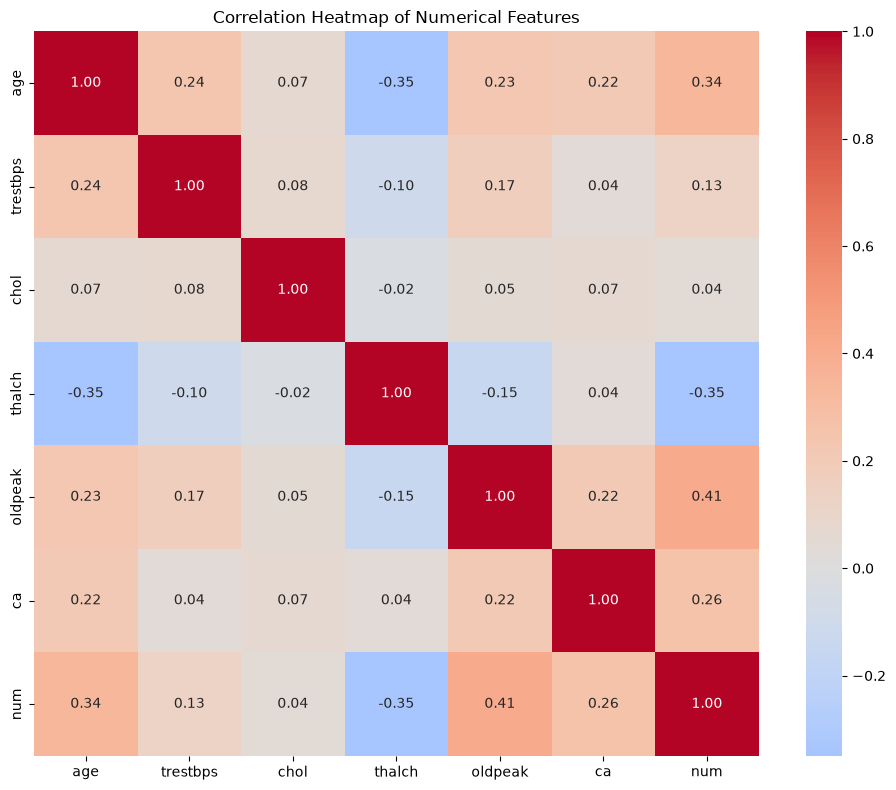

Correlation heatmap saved successfully.


In [96]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../reports/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully.")

In [97]:
target_correlation = (
    correlation_matrix["num"]
    .drop("num")
    .sort_values(key=abs, ascending=False)
)

target_correlation

oldpeak     0.411588
thalch     -0.349173
age         0.339596
ca          0.261797
trestbps    0.130309
chol        0.042751
Name: num, dtype: float64

In [98]:
target_correlation

oldpeak     0.411588
thalch     -0.349173
age         0.339596
ca          0.261797
trestbps    0.130309
chol        0.042751
Name: num, dtype: float64

## 6. Feature Analysis

In [99]:
categorical_features = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for feature in categorical_features:
    print(f"\n{'=' * 70}")
    print(f"Feature: {feature}")
    
    distribution = pd.crosstab(
        df_clean[feature],
        df_clean["num"],
        normalize="index"
    ).round(3)
    
    print(distribution)


Feature: sex
num         0      1      2      3      4
sex                                      
Female  0.742  0.155  0.052  0.041  0.010
Male    0.368  0.324  0.136  0.136  0.036

Feature: dataset
num                0      1      2      3      4
dataset                                         
Cleveland      0.543  0.181  0.118  0.115  0.043
Hungary        0.638  0.362  0.000  0.000  0.000
Switzerland    0.065  0.390  0.260  0.244  0.041
VA Long Beach  0.255  0.280  0.205  0.210  0.050

Feature: cp
num                  0      1      2      3      4
cp                                                
asymptomatic     0.210  0.397  0.179  0.167  0.046
atypical angina  0.862  0.109  0.011  0.017  0.000
non-anginal      0.642  0.181  0.069  0.088  0.020
typical angina   0.565  0.261  0.087  0.065  0.022

Feature: fbs
num        0      1      2      3      4
fbs                                     
False  0.469  0.289  0.110  0.102  0.029
True   0.319  0.283  0.167  0.196  0.036

Feature:

In [100]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

target_feature_summary = df_clean.groupby("num")[numerical_features].mean().round(2)

target_feature_summary

,age,trestbps,chol,thalch,oldpeak,ca
num,,,,,,
0,50.55,129.92,240.10,148.37,0.42,0.11
1,53.53,132.72,252.46,131.48,0.97,0.16
2,57.58,133.35,246.69,129.39,1.29,0.40
3,59.21,136.50,245.52,122.87,1.42,0.50
4,59.21,137.79,245.16,128.71,2.18,0.79


In [101]:
target_feature_summary.to_csv(
    "../reports/numerical_features_by_target.csv"
)

print("Numerical feature summary saved successfully.")

Numerical feature summary saved successfully.


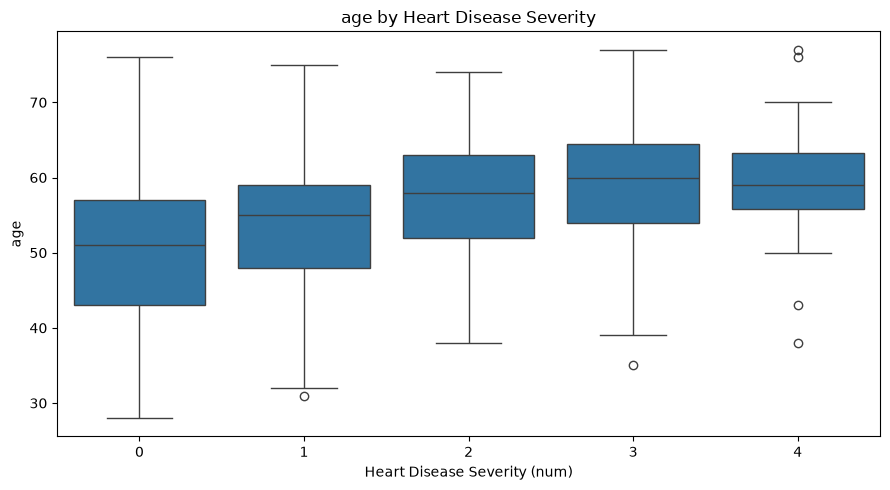

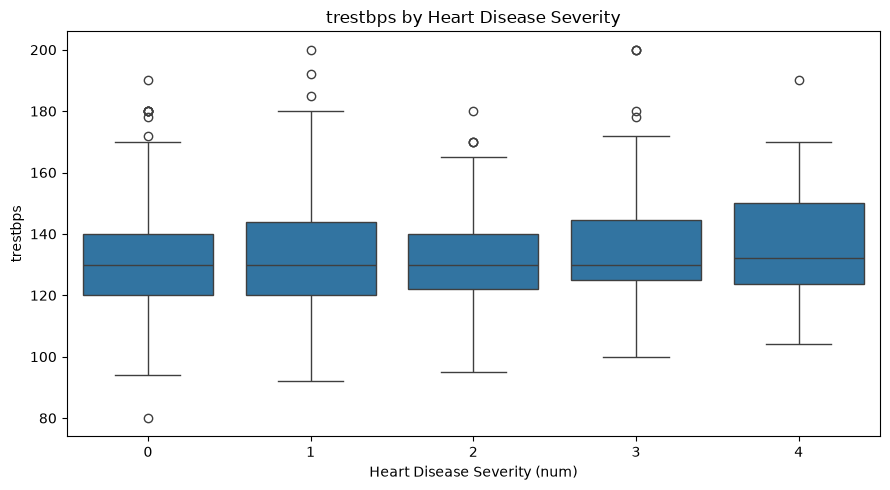

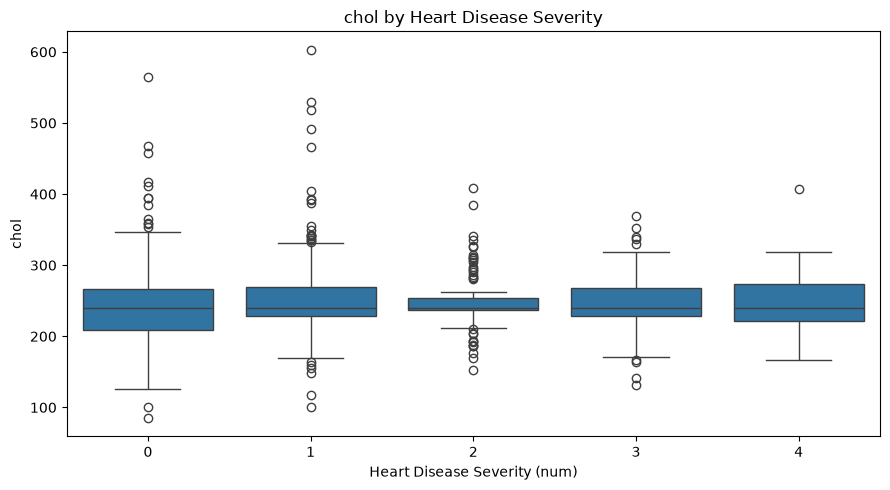

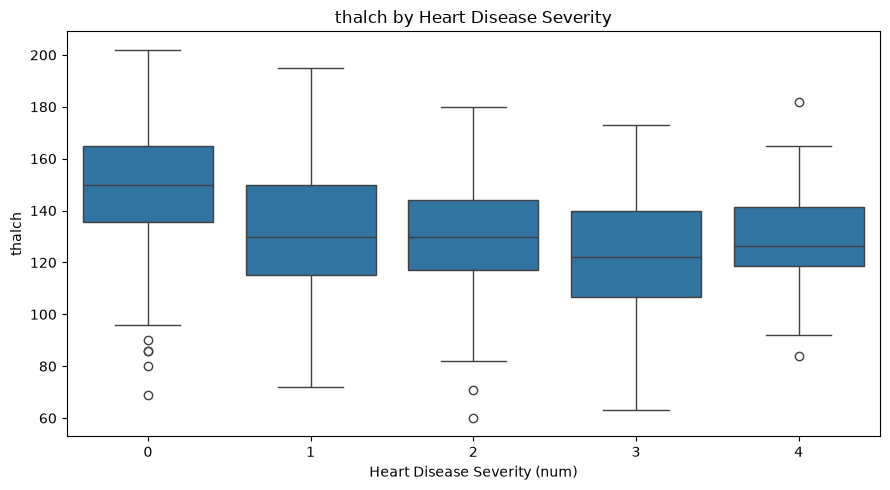

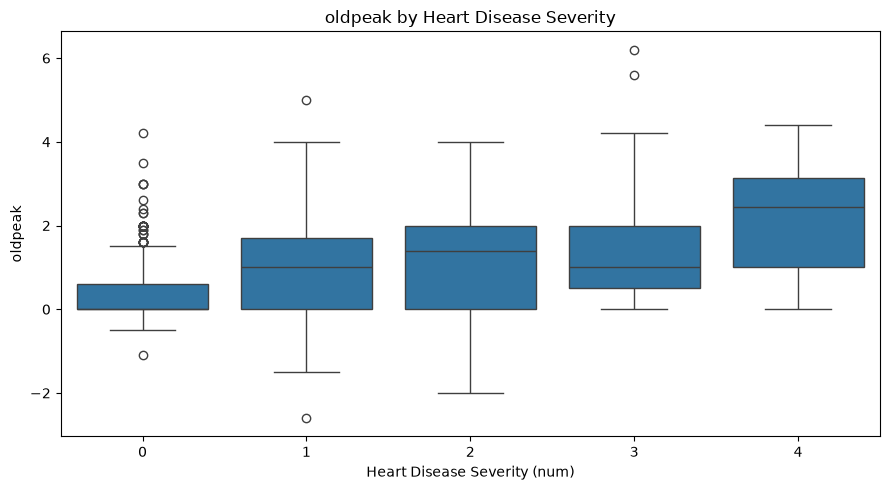

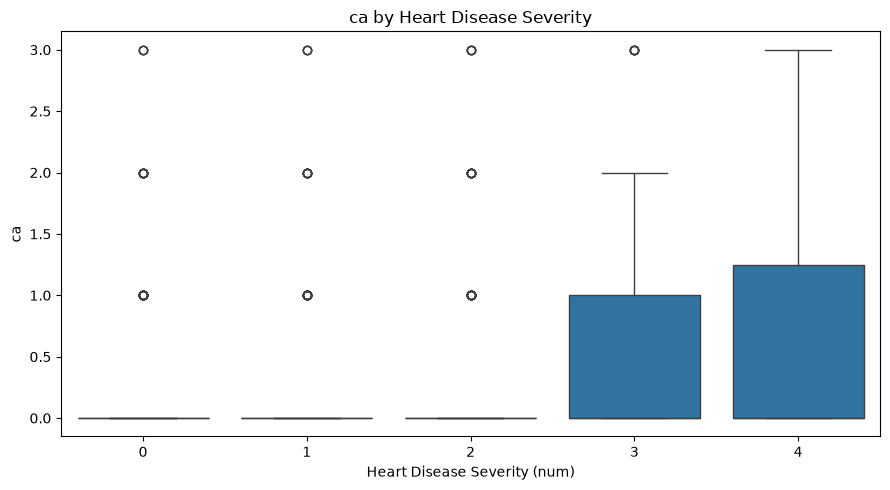

In [102]:
for feature in numerical_features:
    plt.figure(figsize=(9, 5))
    
    sns.boxplot(
        data=df_clean,
        x="num",
        y=feature
    )
    
    plt.title(f"{feature} by Heart Disease Severity")
    plt.xlabel("Heart Disease Severity (num)")
    plt.ylabel(feature)
    
    plt.tight_layout()
    
    plt.savefig(
        f"../reports/{feature}_by_target_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [103]:
for feature in numerical_features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[feature] < lower_bound) |
        (df_clean[feature] > upper_bound)
    ]
    
    print(f"{feature}: {len(outliers)} potential outliers")

age: 0 potential outliers
trestbps: 27 potential outliers
chol: 47 potential outliers
thalch: 2 potential outliers
oldpeak: 16 potential outliers
ca: 128 potential outliers


## 7. Machine Learning Preparation

In [104]:
print("Target variable:", "num")
print("Target classes:", sorted(df_clean["num"].unique()))
print("\nTarget distribution:")
print(df_clean["num"].value_counts().sort_index())

Target variable: num
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Target distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [105]:
df_clean["heart_disease"] = (
    df_clean["num"] > 0
).astype(int)

print(df_clean["heart_disease"].value_counts())

heart_disease
1    509
0    411
Name: count, dtype: int64


In [106]:
target_binary_summary = pd.DataFrame({
    "Count": df_clean["heart_disease"].value_counts().sort_index(),
    "Percentage": (
        df_clean["heart_disease"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_binary_summary

,Count,Percentage
heart_disease,,
0,411,44.67
1,509,55.33


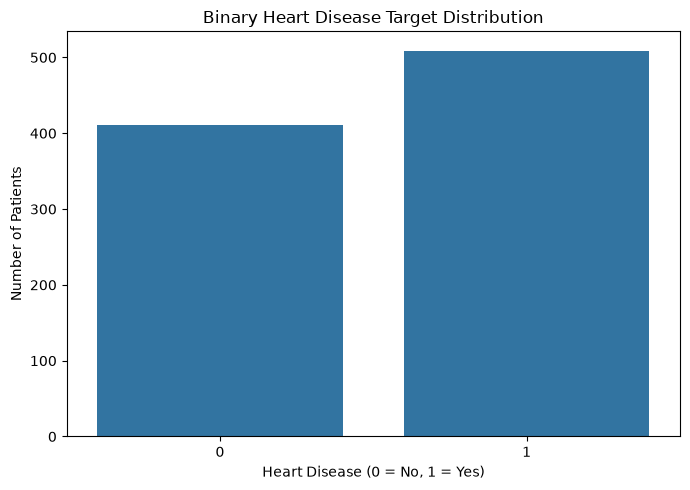

In [107]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="heart_disease"
)

plt.title("Binary Heart Disease Target Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../reports/binary_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
target_binary_summary

,Count,Percentage
heart_disease,,
0,411,44.67
1,509,55.33


In [109]:
# Features
X = df_clean.drop(columns=["num", "heart_disease"])

# Target
y = df_clean["heart_disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (920, 17)
Target shape: (920,)


In [110]:
print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'ca_missing', 'thal_missing', 'slope_missing']


In [111]:
print("Number of features:", X.shape[1])

Number of features: 17


In [112]:
print(y.value_counts())

heart_disease
1    509
0    411
Name: count, dtype: int64


In [113]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of features:", X.shape[1])

print("\nFeature columns:")
for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

Features shape: (920, 17)
Target shape: (920,)

Number of features: 17

Feature columns:
1. age
2. sex
3. dataset
4. cp
5. trestbps
6. chol
7. fbs
8. restecg
9. thalch
10. exang
11. oldpeak
12. slope
13. ca
14. thal
15. ca_missing
16. thal_missing
17. slope_missing


In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (736, 17)
y_train: (736,)

Testing set:
X_test: (184, 17)
y_test: (184,)


In [115]:
print("Training target distribution:")
print(y_train.value_counts())
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target distribution:")
print(y_test.value_counts())
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training target distribution:
heart_disease
1    407
0    329
Name: count, dtype: int64
heart_disease
1    55.3
0    44.7
Name: proportion, dtype: float64

Testing target distribution:
heart_disease
1    102
0     82
Name: count, dtype: int64
heart_disease
1    55.43
0    44.57
Name: proportion, dtype: float64


In [116]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'ca_missing', 'thal_missing', 'slope_missing']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## Preprocessing Pipeline

In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [118]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [119]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [121]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

print("\nTraining data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Preprocessing completed successfully.

Training data shape: (736, 34)
Testing data shape: (184, 34)


In [122]:
preprocessor.fit_transform(X_train)

array([[-0.06314684,  1.56027016, -0.10359879, ...,  0.        ,
         0.        ,  1.        ],
       [ 2.1805258 , -0.11641087, -0.10359879, ...,  0.        ,
         0.        ,  0.        ],
       [-0.06314684, -0.45174708, -0.0383732 , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.32579336,  1.00137648, -0.10359879, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.47106093,  1.00137648,  0.70706206, ...,  0.        ,
         1.        ,  0.        ],
       [-1.98629482, -0.67530455,  1.17295911, ...,  0.        ,
         0.        ,  0.        ]], shape=(736, 34))

In [123]:
preprocessor.transform(X_test)

array([[-0.49051306, -0.11641087, -0.72790083, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.79158559, -0.67530455,  0.68842618, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.15053627,  2.23094257,  0.27843678, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.27682995,  0.44248281, -0.10359879, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.47106093, -0.89886202, -0.10359879, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.15053627, -0.22818961, -0.74653671, ...,  0.        ,
         0.        ,  1.        ]], shape=(184, 34))

In [124]:
print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("\nMissing values in training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in testing data:",
      np.isnan(X_test_processed).sum())

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>

Missing values in training data: 0
Missing values in testing data: 0


In [125]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of processed features: 34

Processed features:
1. num__age
2. num__trestbps
3. num__chol
4. num__thalch
5. num__oldpeak
6. num__ca
7. num__ca_missing
8. num__thal_missing
9. num__slope_missing
10. cat__sex_Female
11. cat__sex_Male
12. cat__dataset_Cleveland
13. cat__dataset_Hungary
14. cat__dataset_Switzerland
15. cat__dataset_VA Long Beach
16. cat__cp_asymptomatic
17. cat__cp_atypical angina
18. cat__cp_non-anginal
19. cat__cp_typical angina
20. cat__fbs_False
21. cat__fbs_True
22. cat__restecg_lv hypertrophy
23. cat__restecg_normal
24. cat__restecg_st-t abnormality
25. cat__exang_False
26. cat__exang_True
27. cat__slope_Missing
28. cat__slope_downsloping
29. cat__slope_flat
30. cat__slope_upsloping
31. cat__thal_Missing
32. cat__thal_fixed defect
33. cat__thal_normal
34. cat__thal_reversable defect


## Baseline Model

In [126]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [127]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [128]:
y_pred_logistic = logistic_model.predict(X_test_processed)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8478
Precision: 0.8304
Recall   : 0.9118
F1-Score : 0.8692
ROC-AUC  : 0.9213


In [130]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.88      0.77      0.82        82
   Heart Disease       0.83      0.91      0.87       102

        accuracy                           0.85       184
       macro avg       0.85      0.84      0.84       184
    weighted avg       0.85      0.85      0.85       184



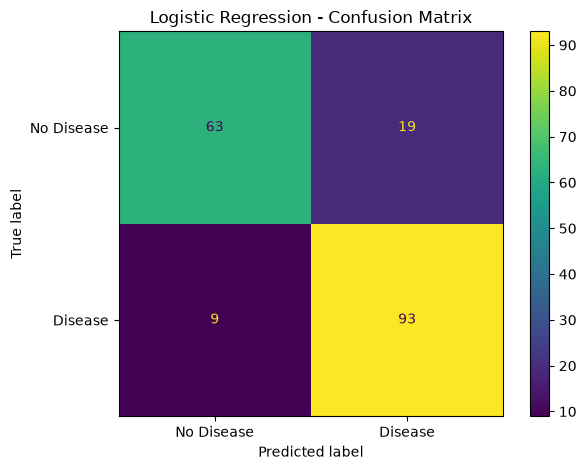

In [131]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

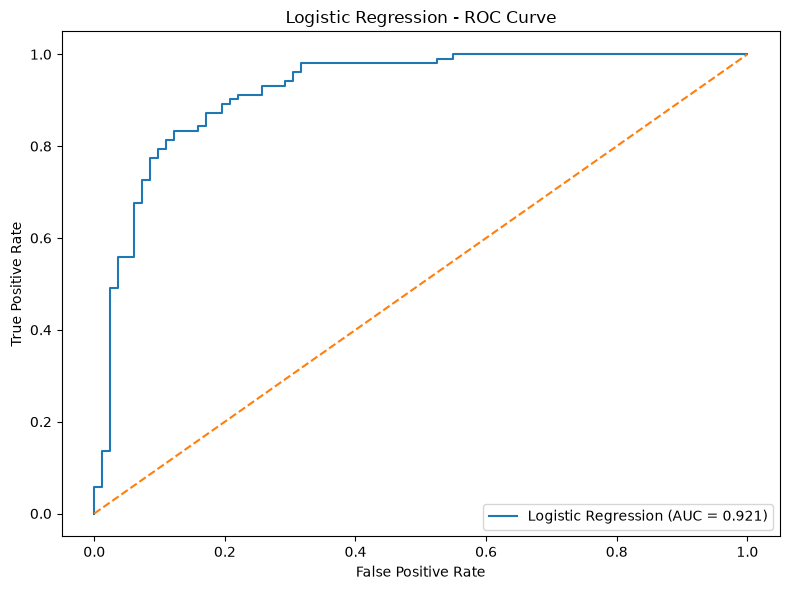

In [132]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/logistic_regression_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Decision Tree Classifier

In [133]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [134]:
y_pred_tree = decision_tree_model.predict(X_test_processed)

y_prob_tree = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [135]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

print("Decision Tree Performance")
print("--------------------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")

Decision Tree Performance
--------------------------------
Accuracy : 0.8043
Precision: 0.8000
Recall   : 0.8627
F1-Score : 0.8302
ROC-AUC  : 0.8478


In [136]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.81      0.73      0.77        82
   Heart Disease       0.80      0.86      0.83       102

        accuracy                           0.80       184
       macro avg       0.81      0.80      0.80       184
    weighted avg       0.80      0.80      0.80       184



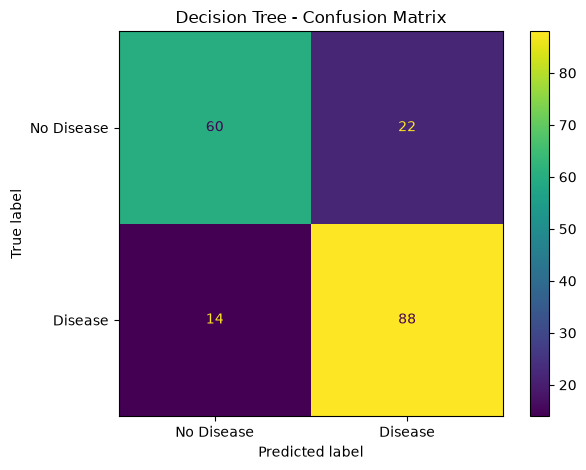

In [137]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

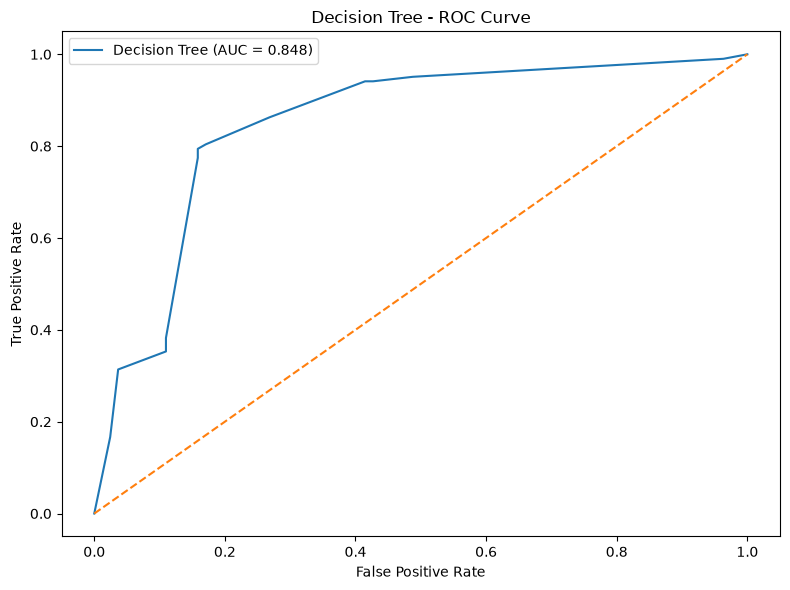

In [138]:
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Random Forest Classifier

In [139]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [140]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [141]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
--------------------------------
Accuracy : 0.8370
Precision: 0.8273
Recall   : 0.8922
F1-Score : 0.8585
ROC-AUC  : 0.9324


In [142]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.85      0.77      0.81        82
   Heart Disease       0.83      0.89      0.86       102

        accuracy                           0.84       184
       macro avg       0.84      0.83      0.83       184
    weighted avg       0.84      0.84      0.84       184



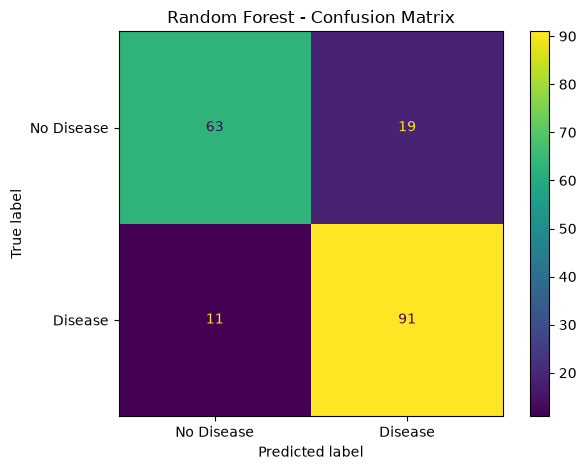

In [143]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

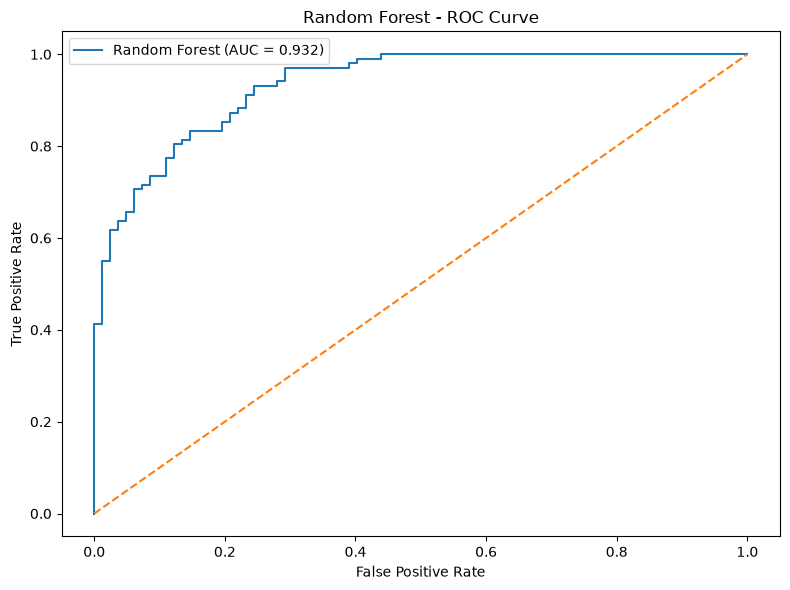

In [144]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [145]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8478,0.8304,0.9118,0.8692,0.9213
1,Decision Tree,0.8043,0.8000,0.8627,0.8302,0.8478
2,Random Forest,0.8370,0.8273,0.8922,0.8585,0.9324


In [146]:
model_comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


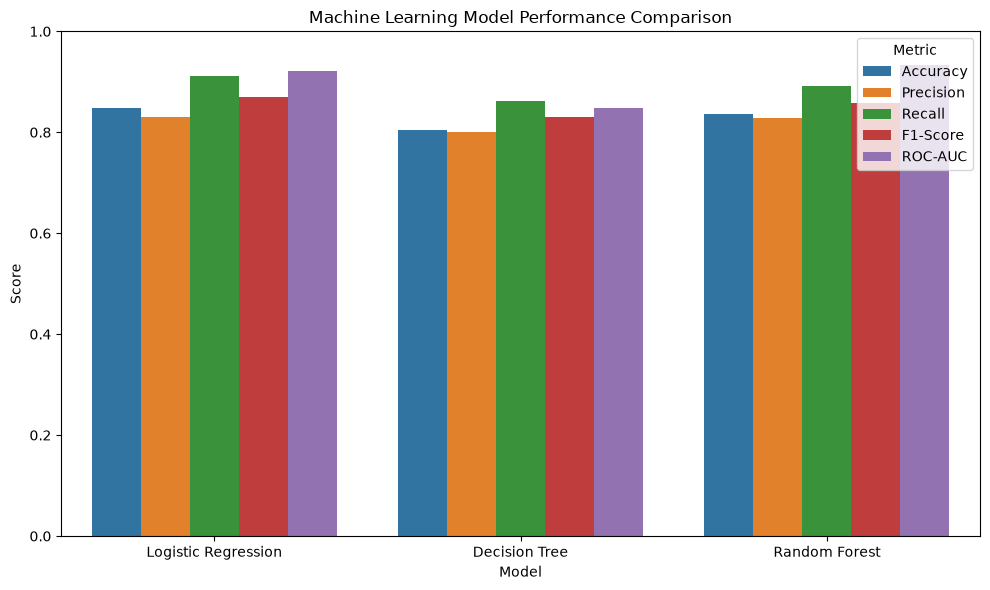

In [147]:
plt.figure(figsize=(10, 6))

model_comparison_melted = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=model_comparison_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "../reports/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest

In [148]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [149]:
y_pred_rf = random_forest_model.predict(X_test_processed)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [150]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.8370
Precision: 0.8273
Recall   : 0.8922
F1-Score : 0.8585
ROC-AUC  : 0.9324


In [151]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.85      0.77      0.81        82
   Heart Disease       0.83      0.89      0.86       102

        accuracy                           0.84       184
       macro avg       0.84      0.83      0.83       184
    weighted avg       0.84      0.84      0.84       184



In [152]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8478,0.8304,0.9118,0.8692,0.9213
1,Decision Tree,0.8043,0.8000,0.8627,0.8302,0.8478
2,Random Forest,0.8370,0.8273,0.8922,0.8585,0.9324


In [153]:
model_comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [154]:
best_model_row = model_comparison.loc[
    model_comparison["F1-Score"].idxmax()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model        Logistic Regression
Accuracy                  0.8478
Precision                 0.8304
Recall                    0.9118
F1-Score                  0.8692
ROC-AUC                   0.9213
Name: 0, dtype: object


In [155]:
best_model_name = best_model_row["Model"]

print(f"Selected model: {best_model_name}")

Selected model: Logistic Regression


## Final Model Evaluation

In [156]:
if best_model_name == "Logistic Regression":
    final_model = logistic_model
    y_pred_final = y_pred_logistic
    y_prob_final = y_prob_logistic

elif best_model_name == "Decision Tree":
    final_model = decision_tree_model
    y_pred_final = y_pred_tree
    y_prob_final = y_prob_tree

elif best_model_name == "Random Forest":
    final_model = random_forest_model
    y_pred_final = y_pred_rf
    y_prob_final = y_prob_rf

print("Final model:", best_model_name)

Final model: Logistic Regression


In [157]:
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_metrics.round(4)

,Metric,Score
0,Accuracy,0.8478
1,Precision,0.8304
2,Recall,0.9118
3,F1-Score,0.8692
4,ROC-AUC,0.9213


In [158]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm_final)

Confusion Matrix:
[[63 19]
 [ 9 93]]


In [159]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.88      0.77      0.82        82
   Heart Disease       0.83      0.91      0.87       102

        accuracy                           0.85       184
       macro avg       0.85      0.84      0.84       184
    weighted avg       0.85      0.85      0.85       184



In [160]:
final_metrics.to_csv(
    "../reports/final_model_metrics.csv",
    index=False
)

print("Final model metrics saved successfully.")

Final model metrics saved successfully.


In [161]:
print("Selected model:", best_model_name)

Selected model: Logistic Regression


In [162]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
15,cat__cp_asymptomatic,0.112571
3,num__thalch,0.081760
4,num__oldpeak,0.081720
0,num__age,0.072460
24,cat__exang_False,0.065515
16,cat__cp_atypical angina,0.064174
25,cat__exang_True,0.060146
2,num__chol,0.054474
13,cat__dataset_Switzerland,0.036806
28,cat__slope_flat,0.035767


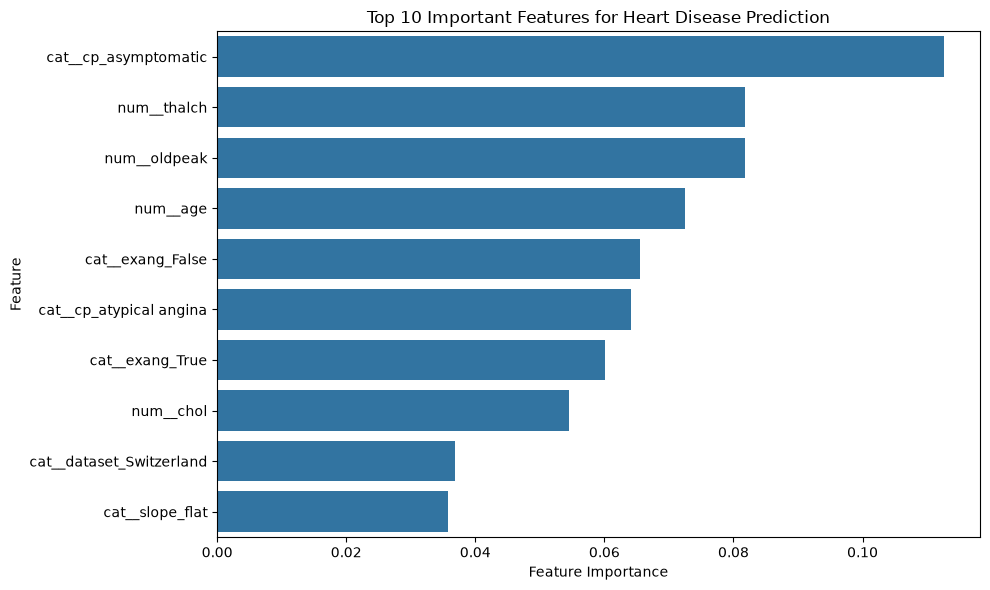

In [163]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Heart Disease Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [164]:
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [165]:
print(best_model_name)

Logistic Regression


Logistic Regression Feature Analysis


In [166]:
logistic_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

logistic_feature_importance["Absolute_Coefficient"] = (
    logistic_feature_importance["Coefficient"].abs()
)

logistic_feature_importance = logistic_feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

logistic_feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
13,cat__dataset_Switzerland,1.534716,1.534716
12,cat__dataset_Hungary,-0.948656,0.948656
15,cat__cp_asymptomatic,0.942736,0.942736
16,cat__cp_atypical angina,-0.836825,0.836825
5,num__ca,0.740237,0.740237
28,cat__slope_flat,0.708207,0.708207
10,cat__sex_Male,0.597857,0.597857
6,num__ca_missing,0.572289,0.572289
9,cat__sex_Female,-0.557119,0.557119
32,cat__thal_normal,-0.539860,0.539860


In [167]:
top_logistic_features = logistic_feature_importance.head(10)

top_logistic_features

,Feature,Coefficient,Absolute_Coefficient
13,cat__dataset_Switzerland,1.534716,1.534716
12,cat__dataset_Hungary,-0.948656,0.948656
15,cat__cp_asymptomatic,0.942736,0.942736
16,cat__cp_atypical angina,-0.836825,0.836825
5,num__ca,0.740237,0.740237
28,cat__slope_flat,0.708207,0.708207
10,cat__sex_Male,0.597857,0.597857
6,num__ca_missing,0.572289,0.572289
9,cat__sex_Female,-0.557119,0.557119
32,cat__thal_normal,-0.539860,0.539860


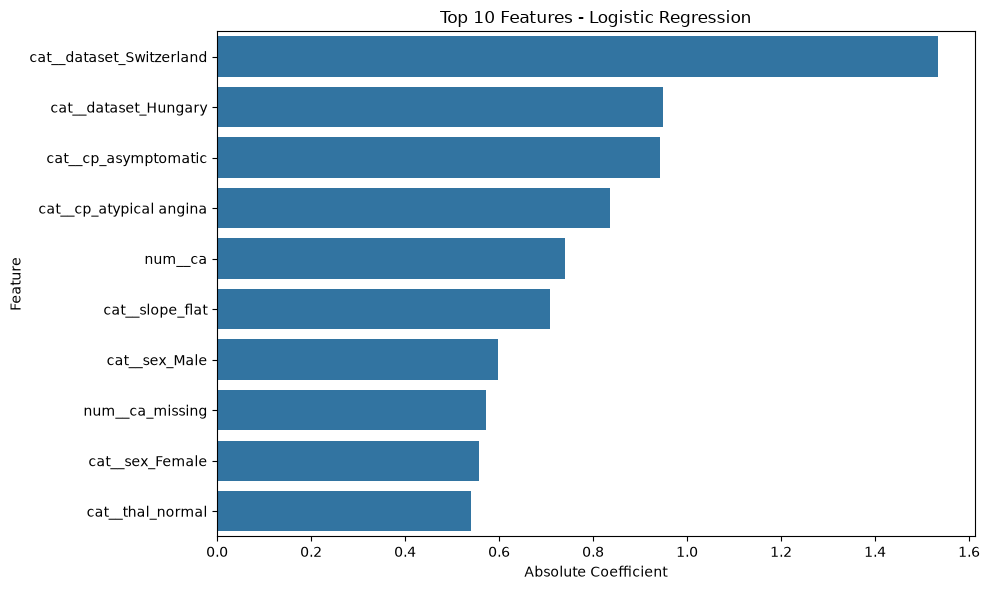

In [168]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_logistic_features,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Top 10 Features - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../reports/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [169]:
print("Features positively associated with heart disease prediction:")
print(
    logistic_feature_importance[
        logistic_feature_importance["Coefficient"] > 0
    ].head(10)
)

print("\nFeatures negatively associated with heart disease prediction:")
print(
    logistic_feature_importance[
        logistic_feature_importance["Coefficient"] < 0
    ].head(10)
)

Features positively associated with heart disease prediction:
                        Feature  Coefficient  Absolute_Coefficient
13     cat__dataset_Switzerland     1.534716              1.534716
15         cat__cp_asymptomatic     0.942736              0.942736
5                       num__ca     0.740237              0.740237
28              cat__slope_flat     0.708207              0.708207
10                cat__sex_Male     0.597857              0.597857
6               num__ca_missing     0.572289              0.572289
25              cat__exang_True     0.468419              0.468419
4                  num__oldpeak     0.466987              0.466987
33  cat__thal_reversable defect     0.445997              0.445997
2                     num__chol     0.248502              0.248502

Features negatively associated with heart disease prediction:
                       Feature  Coefficient  Absolute_Coefficient
12        cat__dataset_Hungary    -0.948656              0.948656
16    

In [170]:
df_clean.to_csv(
    "../data/processed/heart_disease_final.csv",
    index=False
)

print("Final processed dataset saved successfully.")

Final processed dataset saved successfully.


In [171]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [172]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [173]:
print("Final model:", best_model_name)
print("Final accuracy:", round(final_accuracy, 4))
print("Final precision:", round(final_precision, 4))
print("Final recall:", round(final_recall, 4))
print("Final F1-score:", round(final_f1, 4))
print("Final ROC-AUC:", round(final_roc_auc, 4))

Final model: Logistic Regression
Final accuracy: 0.8478
Final precision: 0.8304
Final recall: 0.9118
Final F1-score: 0.8692
Final ROC-AUC: 0.9213


In [174]:
print("Final dataset shape:", df_clean.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Final dataset shape: (920, 19)
Training shape: (736, 17)
Testing shape: (184, 17)


In [176]:
logistic_feature_importance.to_csv(
    "../reports/logistic_feature_importance.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.
